# TP6 --- HINTS: hybrid iterative solver with a DeepONet corrector

## SciML, Toulouse INP / ENSEEIHT --- Spring 2026

In this TP, we build the hybrid solver, called HINTS, which effectivelly combines DeepONet with Jacobi iteration.


---
## Part 1 --- Model problem and direct solver

We consider the 1-D Poisson BVP
$$
  -u''(x) = f(x), \qquad x \in (0,1), \qquad u(0) = u(1) = 0.
$$
Second-order finite differences on interior nodes
$x_i = i h$, $h = 1/(n+1)$, give the linear system
$$
  A \mathbf u = \mathbf b, \qquad
  A = h^{-2} \operatorname{tridiag}(-1, 2, -1), \qquad
  b_i = f(x_i).
$$
$A$ is symmetric positive-definite with known sine eigenpairs
$$
  \lambda_j = \tfrac{4}{h^2} \sin^2\!\tfrac{j\pi h}{2},
  \qquad
  \phi_j^{(i)} = \sqrt{2h}\, \sin(i j \pi h),
  \qquad j = 1, \dots, n.
$$

**Right-hand side:**  We pick a manufactured RHS made of a handful of
sine modes,
$$
  f(x) \;=\; \sum_{k \in \mathcal K} \sin(k \pi x), \qquad
  \mathcal K = \{1, 4, 8\}.
$$


n = 31,  h = 3.1250e-02,  kappa(A) ~ 414.3


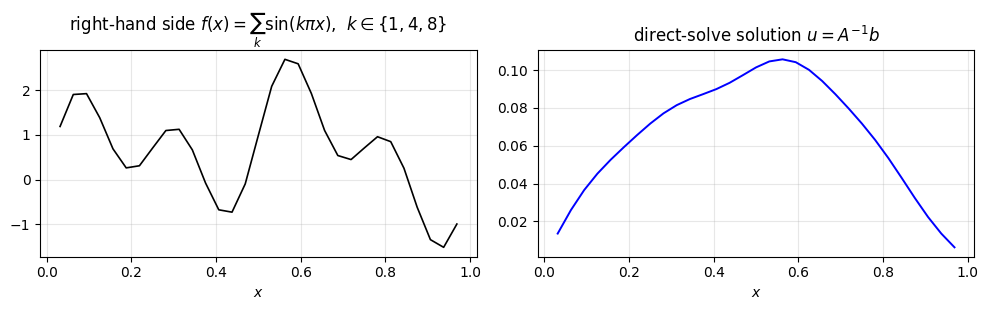

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn

torch.set_default_dtype(torch.float64)
np.random.seed(0); torch.manual_seed(0)

# --- Grid and stiffness matrix ---
N       = 31
H       = 1.0 / (N + 1)
x_int   = np.linspace(H, 1.0 - H, N)

A       = (np.diag(2.0 * np.ones(N))
           - np.diag(np.ones(N-1),  1)
           - np.diag(np.ones(N-1), -1)) / H**2
diag_A  = np.diag(A)

# --- Eigenstructure (sine basis) ---
j_all   = np.arange(1, N + 1)
lam     = (4.0 / H**2) * np.sin(0.5 * j_all * np.pi * H)**2
Phi     = np.sqrt(2.0 * H) * np.sin(np.outer(np.arange(1, N+1), j_all) * np.pi * H)

# --- Right-hand side and direct solve ---
K_MODES = [1, 4, 8]
f_rhs   = np.sum([np.sin(k * np.pi * x_int) for k in K_MODES], axis=0)
u_direct = np.linalg.solve(A, f_rhs)

print(f"n = {N},  h = {H:.4e},  kappa(A) ~ {lam.max()/lam.min():.1f}")

# --- Plot RHS and direct-solve solution ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(x_int, f_rhs, 'k-', lw=1.2)
axes[0].set_title(r'right-hand side $f(x) = \sum_{k} \sin(k\pi x)$,  $k \in \{1,4,8\}$')
axes[0].set_xlabel('$x$'); axes[0].grid(alpha=0.3)
axes[1].plot(x_int, u_direct, 'b-', lw=1.4)
axes[1].set_title(r'direct-solve solution $u = A^{-1} b$')
axes[1].set_xlabel('$x$'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## Part 2 --- Damped Jacobi as a *smoother*

Damped Jacobi with relaxation parameter $\omega$ reads
$$
  u_{k+1} = u_k + \omega D^{-1}(\mathbf b - A u_k),
  \qquad S_J = I - \omega D^{-1} A,
$$
where $\omega=2/3$ and $S_J$ is the error propagation matrix.

Decomposing the error $e_k = u^\star - u_k = \sum_j c_j^{(k)} \phi_j$, each
mode decays **independently**:
$$
  c_j^{(k)} = \mu_j^{\,k}\, c_j^{(0)}.
$$
We notice that high frequencies are eliminated quickly, while low frequencies stall.


**TODO:** Implement Jacobi iteration and study its convergence with respect to different error modes. 

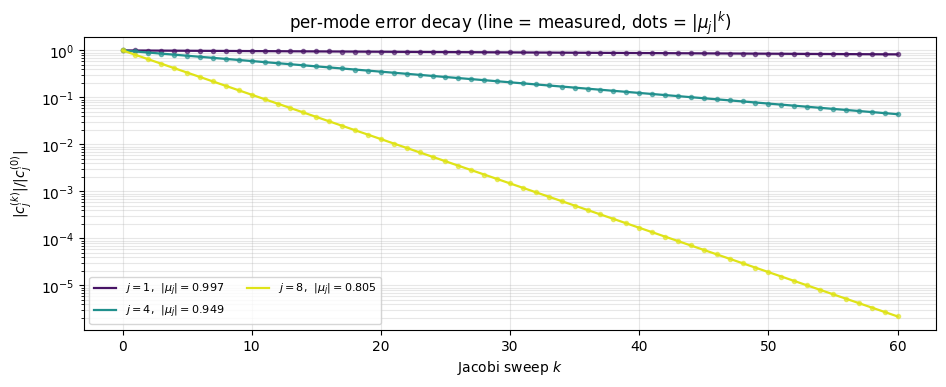

smoothing factor  max |mu_j|, j >= n/2  =  0.3333
low-freq stall    |mu_1|                =  0.996790


In [2]:
OMEGA = 2.0 / 3.0
mu_J  = 1.0 - 2.0 * OMEGA * np.sin(0.5 * j_all * np.pi * H)**2

# --- Run damped Jacobi from u_0 = 0 on the Part 1 problem ---
n_sweeps  = 60
tracked   = K_MODES                                           # same modes as in f
coeff_hist = np.zeros((n_sweeps + 1, len(tracked)))
u_k = np.zeros(N)
for k in range(n_sweeps + 1):
    e_k = u_direct - u_k                                      # error
    for i, jm in enumerate(tracked):
        coeff_hist[k, i] = np.abs(Phi[:, jm-1] @ e_k)
    if k < n_sweeps:
        # TODO:: Perform one damped Jacobi sweep to update u_k, 
        # using OMEGA and diag_A
         u_k = u_k + OMEGA * (f_rhs - A @ u_k) / diag_A

# --- Plot: measured decay vs theory |mu_j|^k ---
fig, axes = plt.subplots(1, 1, figsize=(11, 3.8))
cm = plt.cm.viridis(np.linspace(0.05, 0.95, len(tracked)))
for i, jm in enumerate(tracked):
    c0 = max(coeff_hist[0, i], 1e-30)
    axes.semilogy(coeff_hist[:, i] / c0, '-', color=cm[i], lw=1.6,
                     label=fr'$j={jm}$,  $|\mu_j|={abs(mu_J[jm-1]):.3f}$')
    axes.semilogy(abs(mu_J[jm-1])**np.arange(n_sweeps+1),
                     'o', color=cm[i], ms=3, alpha=0.6)
axes.set_xlabel('Jacobi sweep $k$')
axes.set_ylabel(r'$|c_j^{(k)}| / |c_j^{(0)}|$')
axes.set_title(r'per-mode error decay (line = measured, dots = $|\mu_j|^k$)')
axes.grid(True, which='both', alpha=0.3)
axes.legend(ncol=2, fontsize=8, loc='lower left')

plt.show()

print(f"smoothing factor  max |mu_j|, j >= n/2  =  {np.max(np.abs(mu_J[N//2:])):.4f}")
print(f"low-freq stall    |mu_1|                =  {abs(mu_J[0]):.6f}")


**Question:** How does the performance of Jacobi method relates to the spectral bias of neural networks. 

---
## Part 3 --- DeepONet: learn $f \mapsto u$

We approximate the solution operator $\mathcal N : f \mapsto A^{-1} f$
by a small **DeepONet** ,
$$
  \mathcal N_\theta(f)(x) \;=\; x(1-x)\, \sum_{k=1}^{p}
     b_k\bigl(f(x_1),\dots,f(x_m)\bigr)\, t_k(x),
$$
with branch and trunk MLPs and a hard Dirichlet BC mask $x(1-x)$.  Sensors
$\{x_i\}$ coincide with the FD grid, so $m = n = 31$.  

The final layers carry no bias so that $\mathcal N_\theta(0) = \mathcal N_\theta(1) = 0$, which is essential so that a
zero residual produces a zero correction in HINTS below.

**Training distribution:**  We sample $f$ from a smooth Gaussian random
field (squared-exponential kernel, length scale $\ell = 0.1$) and
compute the label $u = A^{-1} f$ using direct solver.

**Scale equivariance:**  Because $A^{-1}$ is linear, $A^{-1}(c f) = c
A^{-1}(f)$.  We enforce this explicitly by normalising each input to
unit $\ell^2$-norm inside the network,
$\mathcal N_\theta(f) = \|f\| \cdot \mathcal N_\theta^{\text{raw}}(f/\|f\|)$.
This matters at HINTS deployment, where $\mathcal N_\theta$ is applied
to residuals of widely varying magnitude.


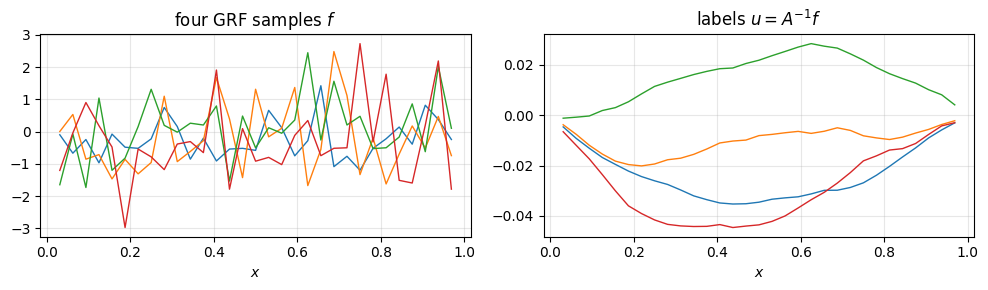

training pairs: 3000,  test pairs: 200


In [18]:
# --- GRF sampler (squared-exponential kernel) ---
def grf_samples(n_samples, ell=0.01, jitter=1e-10):
    K = np.exp(-(x_int[:, None] - x_int[None, :])**2 / (2 * ell**2))
    K += jitter * np.eye(N)
    L = np.linalg.cholesky(K)
    return (L @ np.random.randn(N, n_samples)).T            # (n_samples, N)

# --- Training / test sets ---
f_tr_np = grf_samples(3000, ell=0.01)
u_tr_np = np.linalg.solve(A, f_tr_np.T).T
f_te_np = grf_samples(200,  ell=0.01)
u_te_np = np.linalg.solve(A, f_te_np.T).T

# --- Visualise a few GRF pairs ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
for k in range(4):
    axes[0].plot(x_int, f_tr_np[k], lw=1)
    axes[1].plot(x_int, u_tr_np[k], lw=1)
axes[0].set_title(r'four GRF samples $f$'); axes[0].set_xlabel('$x$'); axes[0].grid(alpha=0.3)
axes[1].set_title(r'labels $u = A^{-1} f$'); axes[1].set_xlabel('$x$'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"training pairs: {len(f_tr_np)},  test pairs: {len(f_te_np)}")


**Question:** Why did we choose $\ell=0.1$ for sampling right-hand sides? How does sampled right-hand sides change when $\ell$ changes? Experiment with the parameter and monitor your observations. 

## Implementation of DeepOnet, consisting of branch and trunk network.
TODO:: Implement the forward propagation through the DeepOnet (function '_raw(., ., .)'). Do not forget to impose Hard BC conditions.

In [19]:
# --- Small DeepONet with scale-equivariance wrapper ---
class DeepONet(nn.Module):
    def __init__(self, m_sensors, p=64, width=64, depth=3):
        super().__init__()
        def mlp(d_in):
            layers = [nn.Linear(d_in, width), nn.Tanh()]
            for _ in range(depth - 1):
                layers += [nn.Linear(width, width), nn.Tanh()]
            layers += [nn.Linear(width, p, bias=False)]
            return nn.Sequential(*layers)
        self.branch = mlp(m_sensors)
        self.trunk  = mlp(1)

    def _raw(self, f_sensors, x_query):
        # TODO:: Implement the raw DeepONet output by applying the branch and trunk MLPs to 
        # f_sensors and x_query, respectively, and combining them appropriately.
        # Note that the branch output should be a vector of length p, 
        # and the trunk output should also be a vector of length p, 
        # so that we can take their inner product to get a scalar output for each query point.

        b  = self.branch(f_sensors)
        t  = self.trunk(x_query)
        bc = (x_query[:,0]*(1.0-x_query[:,0]) ).unsqueeze(0)

        don_output = bc * (b@t.T)

        return don_output

    def forward(self, f_sensors, x_query):
        nrm = f_sensors.norm(dim=-1, keepdim=True).clamp(min=1e-30)
        return nrm * self._raw(f_sensors / nrm, x_query)

model = DeepONet(N, p=64, width=64, depth=3)
x_q_t = torch.from_numpy(x_int).unsqueeze(1)
print(f"DeepONet parameters: {sum(p.numel() for p in model.parameters()):,}")


DeepONet parameters: 27,008


  it   500/5000  train 2.28e-07  test 2.52e-07
  it  1000/5000  train 1.91e-07  test 1.99e-07
  it  1500/5000  train 1.10e-07  test 1.28e-07
  it  2000/5000  train 1.71e-07  test 1.48e-07
  it  2500/5000  train 1.01e-07  test 1.22e-07
  it  3000/5000  train 1.06e-07  test 1.22e-07
  it  3500/5000  train 1.05e-07  test 1.22e-07
  it  4000/5000  train 1.04e-07  test 1.22e-07
  it  4500/5000  train 1.05e-07  test 1.22e-07
  it  5000/5000  train 1.06e-07  test 1.22e-07

mean relative L2 error on test set: 17.128%


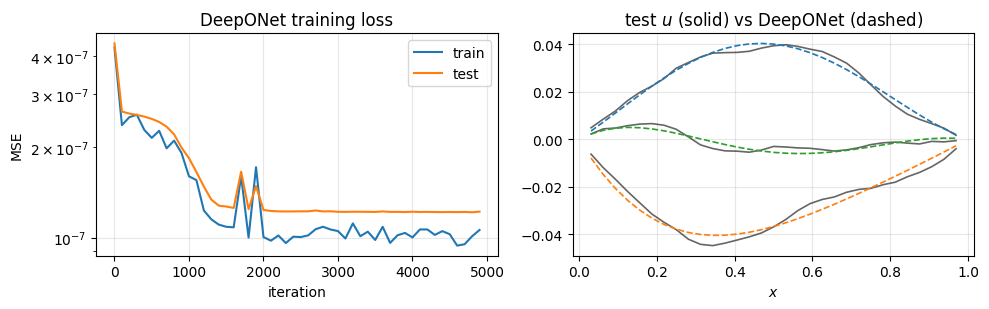

In [20]:
# --- Train DeepONet on unit-normalised GRF pairs ---
f_train = torch.from_numpy(f_tr_np); u_train = torch.from_numpy(u_tr_np)
f_test  = torch.from_numpy(f_te_np); u_test  = torch.from_numpy(u_te_np)

opt   = torch.optim.Adam(model.parameters(), lr=5e-3)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)
N_ITERS, BATCH = 5000, 256
hist = []

def norm_pair(f, u):
    nrm = f.norm(dim=-1, keepdim=True).clamp(min=1e-30)
    return f / nrm, u / nrm

for it in range(N_ITERS):
    idx    = torch.randint(0, len(f_train), (BATCH,))
    fn, un = norm_pair(f_train[idx], u_train[idx])

    # TODO:: Compute the raw DeepONet output for the batch of normalised inputs (fn, x_q_t), 
    # and then compute the MSE loss against the normalised labels un
    pred   = model._raw(fn, x_q_t)
    loss   = ((pred - un)**2).mean()
    
    opt.zero_grad(); 
    loss.backward(); 
    opt.step(); 
    sched.step()


    if (it + 1) % 100 == 0:
        with torch.no_grad():
            fn_te, un_te = norm_pair(f_test, u_test)
            te = ((model._raw(fn_te, x_q_t) - un_te)**2).mean().item()
        hist.append((loss.item(), te))
        if (it + 1) % 500 == 0:
            print(f"  it {it+1:5d}/{N_ITERS}  train {loss.item():.2e}  test {te:.2e}")

# --- Relative L^2 error on test set ---
with torch.no_grad():
    pred_te = model(f_test, x_q_t)
    rel = (((pred_te - u_test)**2).sum(dim=1).sqrt()
           / (u_test**2).sum(dim=1).sqrt()).mean().item()
print(f"\nmean relative L2 error on test set: {rel:.3%}")

# --- Visualise convergence and a prediction ---
hist = np.array(hist)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].semilogy(np.arange(len(hist))*100, hist[:,0], label='train')
axes[0].semilogy(np.arange(len(hist))*100, hist[:,1], label='test')
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('MSE')
axes[0].set_title('DeepONet training loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

with torch.no_grad():
    for k in range(3):
        axes[1].plot(x_int, u_te_np[k], 'k-', lw=1.2, alpha=0.6)
        axes[1].plot(x_int, model(f_test[k:k+1], x_q_t).squeeze(0).numpy(),
                     '--', lw=1.2)
axes[1].set_title(r'test $u$ (solid) vs DeepONet (dashed)')
axes[1].set_xlabel('$x$'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## Part 4 --- HINTS: alternate few iterations of Jacobi with DeepONet call

One HINTS outer iteration reads
$$
  u \;\leftarrow\; S_J^{\,n_s}(u), \\
  u \;\leftarrow\; u \;+\; \mathcal N_\theta\!\bigl(\mathbf b - A u\bigr)
$$
where $n_s$ denotes the number of Jacobi iterations. 

Jacobi damps high frequencies, while the DeepONet, trained on
a smooth input class, supplies the low-frequency correction Jacobi
cannot deliver. 

We compare three sweepers applied to the Part 1 right-hand side:
pure Jacobi ($n_s$ steps) and HINTS with $n_s$ Jacobi pre-smoothing
steps plus one DeepONet correction.


TODO: Implement the HINTs scheme. Perform $n_s$ iterations of Jacobi, recompute the residual and then apply the DeepOnet correction.

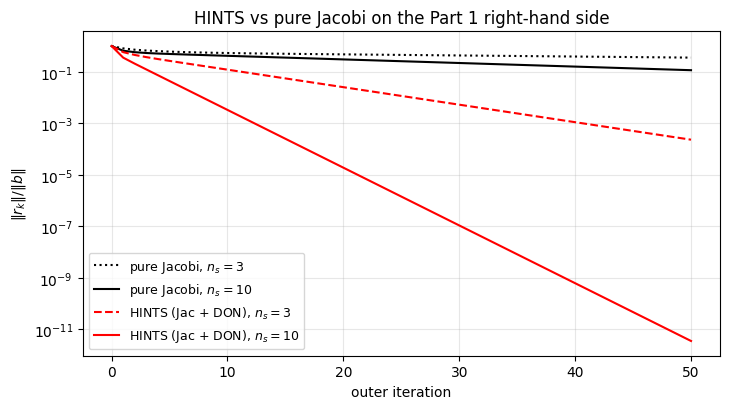

config                                   |r|@1     |r|@10     |r|@40
pure Jacobi, $n_s=3$                  8.13e-01   5.38e-01   3.93e-01
pure Jacobi, $n_s=10$                 6.59e-01   4.19e-01   1.60e-01
HINTS (Jac + DON), $n_s=3$            5.81e-01   1.21e-01   1.11e-03
HINTS (Jac + DON), $n_s=10$           3.56e-01   3.32e-03   6.16e-10


In [22]:
def jacobi_step(u, b):
    # TODO:: Implement one damped Jacobi step to update u, using OMEGA and diag_A
    u_new =  u + OMEGA * (b - A @ u) / diag_A
    return u_new

def pure_jacobi(u, b, n_s=3):
    for _ in range(n_s):
        u = jacobi_step(u, b)
    return u

def hints_sweep(u, b, n_s=3):
    for _ in range(n_s):
        u = jacobi_step(u, b)

    # TODO:: Compute the residual
    r = b - A @ u

    # TODO:: Compute the DeepONet correction for the residual r
    with torch.no_grad():
         corr = model(torch.from_numpy(r).unsqueeze(0), x_q_t).squeeze(0).numpy()

    # TODO: Add the correction to u and return the updated solution
    u_new = u + corr

    return u_new


def run_solver(sweep, b, n_iter=40):
    u   = np.zeros(N)
    bn  = np.linalg.norm(b) + 1e-30
    hist = [np.linalg.norm(b - A @ u) / bn]
    for _ in range(n_iter):
        u = sweep(u, b)
        hist.append(np.linalg.norm(b - A @ u) / bn)
    return u, np.array(hist)

# --- Residual history for the Part 1 problem ---
configs = [
    ('pure Jacobi, $n_s=3$',       lambda u, b: pure_jacobi(u, b, 3)),
    ('pure Jacobi, $n_s=10$',      lambda u, b: pure_jacobi(u, b, 10)),
    ('HINTS (Jac + DON), $n_s=3$', lambda u, b: hints_sweep (u, b, 3)),
    ('HINTS (Jac + DON), $n_s=10$',lambda u, b: hints_sweep (u, b, 10)),
]
hists = {lab: run_solver(sw, f_rhs, n_iter=50)[1] for lab, sw in configs}

fig, ax = plt.subplots(figsize=(7.4, 4.2))
for (lab, _), style in zip(configs, ['k:', 'k-', 'r--', 'r-']):
    ax.semilogy(hists[lab], style, lw=1.5, label=lab)
ax.set_xlabel('outer iteration')
ax.set_ylabel(r'$\|r_k\| / \|b\|$')
ax.set_title('HINTS vs pure Jacobi on the Part 1 right-hand side')
ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'config':35s}  {'|r|@1':>9s}  {'|r|@10':>9s}  {'|r|@40':>9s}")
for lab in hists:
    h = hists[lab]
    print(f"{lab:35s}  {h[1]:9.2e}  {h[10]:9.2e}  {h[40]:9.2e}")


we can use agaus`-seidl pour la methode iterative , pour l'architecture de reseau on pourra penser a F

**Question:** Explain the observed convergence behaviour. 

**Question:** How does the value of $n_s$ changes the performance of the HINTS solver. 

**Question:** Is the HITNS solver mesh independent? Explain how can be HINTs solver adjusted to work for problems with different resolutions. 

**Question:** Do you think method would also work in combination with different iterative scheme, than Jacobi? 